# Adult Census Income – Data Preprocessing & Feature Engineering

Notebook này tập trung xây dựng pipeline tiền xử lý dữ liệu cho dataset Adult Census Income dựa trên kết quả phân tích từ bước EDA.

## Mục tiêu

- Làm sạch và chuẩn hóa dữ liệu đầu vào
- Giảm ảnh hưởng của giá trị thiếu và ngoại lai
- Đưa dữ liệu về dạng phù hợp cho mô hình học máy
- Đánh giá định lượng các phương pháp tiền xử lý

## Nội dung thực hiện

### 1. Xử lý giá trị thiếu có kiểm định
- Giả lập missing theo cơ chế MCAR
- So sánh các phương pháp imputation
- Đánh giá bằng RMSE trên ground truth

### 2. Phát hiện và xử lý ngoại lai
- Áp dụng nhiều phương pháp (IQR, Z-score, Isolation Forest, LOF, DBSCAN)
- Đánh giá bằng tỷ lệ outlier, Jaccard similarity và KS test

### 3. Chuẩn hóa dữ liệu
- So sánh các phương pháp scaling (MinMax, Z-score, Robust, Quantile)
- Đánh giá bằng Levene’s test và violin plot

### 4. Encoding biến phân loại
- Xử lý dữ liệu categorical theo đặc điểm phân phối và phụ thuộc giữa các biến

### 5. Feature selection & Dimensionality reduction
- Lựa chọn đặc trưng và giảm chiều dữ liệu

### 6. Đánh giá mô hình
- Sử dụng F1-score với 5-fold cross-validation

## Ý nghĩa

Notebook hướng đến việc xây dựng một pipeline tiền xử lý có cơ sở định lượng rõ ràng, giúp:
- Cải thiện chất lượng dữ liệu
- Tăng hiệu quả mô hình
- Đảm bảo tính tổng quát hóa

# Import thư viện và cấu hình đường dẫn

In [3]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

from scipy import stats
from scipy.stats import shapiro, normaltest, levene, ks_2samp, chi2_contingency

from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, KFold
from sklearn.preprocessing import (
    OneHotEncoder, OrdinalEncoder, MinMaxScaler, TargetEncoder,
    StandardScaler, RobustScaler, QuantileTransformer, LabelEncoder
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer
from sklearn.metrics import mean_squared_error, f1_score, classification_report, jaccard_score
from sklearn.ensemble import IsolationForest, RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import LocalOutlierFactor
from sklearn.cluster import DBSCAN
from sklearn.feature_selection import SelectKBest, f_classif, chi2, mutual_info_classif, RFECV
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.base import clone

SEED = 42
np.random.seed(SEED)

CURRENT_DIR = os.getcwd()
BASE_DIR = os.path.dirname(CURRENT_DIR)

DATA_DIR = os.path.join(BASE_DIR, "data")
DATA_PATH = os.path.join(DATA_DIR, "raw", "adult.csv")

In [4]:
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.replace("?", pd.NA, inplace=True)
display(df.head())

Shape: (32561, 15)


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,<NA>,77053,HS-grad,9,Widowed,<NA>,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,<NA>,186061,Some-college,10,Widowed,<NA>,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [5]:
target_col = "income"
assert target_col in df.columns, f"Không tìm thấy cột target '{target_col}'"

# Phân loại cột
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in df.columns if c not in numeric_cols + [target_col]]

print("Các cột số:", numeric_cols)
print("Các cột phân loại:", categorical_cols)
print("Biến mục tiêu:", target_col)

Các cột số: ['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']
Các cột phân loại: ['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country']
Biến mục tiêu: income


# Các kỹ thuật tiền xử lý và đánh giá định lượng
## 1. Xử lý giá trị thiếu có kiểm soát
Trong bước này, nhóm tiến hành xử lý giá trị thiếu và đánh giá hiệu quả của các chiến lược điền khuyết nhằm lựa chọn phương pháp phù hợp cho dữ liệu.
### 1.1 Phương pháp
Để đảm bảo tính khách quan và khả năng đánh giá định lượng, nhóm áp dụng phương pháp thực nghiệm có kiểm soát. Cụ thể, một tỷ lệ 10% giá trị thiếu được tạo thêm một cách ngẫu nhiên theo cơ chế MCAR trên các biến số, trong khi dữ liệu gốc được giữ lại làm ground truth. Cách tiếp cận này cho phép so sánh trực tiếp giữa giá trị điền khuyết và giá trị thực tế ban đầu.

Trên cơ sở đó, nhóm triển khai và so sánh các chiến lược điền khuyết phổ biến, bao gồm:
- **Mean Imputation**
- **Median Imputation**
- **Mode Imputation**
- **k-Nearest Neighbors (k-NN Imputation, với k ∈ {3, 5, 10})**
- **MICE (Multiple Imputation by Chained Equations)**

Đối với mỗi phương pháp, dữ liệu sau khi điền khuyết được đánh giá thông qua sai số trên các vị trí bị thiếu giả lập. Phương pháp có sai số thấp hơn được xem là có khả năng khôi phục dữ liệu tốt hơn.

In [6]:
# Ground truth trên biến số
df_num_true = df[numeric_cols].copy()

print("Các cột số dùng để đánh giá:", numeric_cols)
print("Kích thước dữ liệu số:", df_num_true.shape)

missing_rate = 0.10
df_num_missing = df_num_true.copy()

# Tạo thêm 10% missing giả lập theo MCAR trên dữ liệu số
mcar_mask = pd.DataFrame(
    np.random.rand(*df_num_true.shape) < missing_rate,
    columns=df_num_true.columns,
    index=df_num_true.index
)

# Không tạo missing ở những ô vốn đã missing sẵn trong dữ liệu gốc
original_na_mask = df_num_true.isna()
final_mask = mcar_mask & (~original_na_mask)

# Áp missing giả
df_num_missing = df_num_missing.mask(final_mask)

print("Tổng số ô bị xóa giả lập:", final_mask.sum().sum())
print("Tỷ lệ missing giả lập thực tế:", round(final_mask.sum().sum() / df_num_true.size * 100, 2), "%")

Các cột số dùng để đánh giá: ['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']
Kích thước dữ liệu số: (32561, 6)
Tổng số ô bị xóa giả lập: 19586
Tỷ lệ missing giả lập thực tế: 10.03 %


In [7]:
def compute_rmse_on_mask(df_true, df_imputed, mask):
    """
    Tính RMSE chỉ trên các vị trí bị xóa giả lập (mask=True).
    """
    true_values = df_true[mask]
    imputed_values = df_imputed[mask]

    # Chuyển về vector 1 chiều, loại NaN
    true_flat = true_values.stack().values
    imputed_flat = imputed_values.stack().values

    valid = ~np.isnan(true_flat) & ~np.isnan(imputed_flat)

    rmse = np.sqrt(mean_squared_error(true_flat[valid], imputed_flat[valid]))
    return rmse

### 1.2 Kết quả so sánh định lượng (RMSE)

In [8]:
imputation_methods = {
    "Mean": SimpleImputer(strategy="mean"),
    "Median": SimpleImputer(strategy="median"),
    "Mode": SimpleImputer(strategy="most_frequent"),
    "KNN_k3": KNNImputer(n_neighbors=3),
    "KNN_k5": KNNImputer(n_neighbors=5),
    "KNN_k10": KNNImputer(n_neighbors=10),
    "MICE": IterativeImputer(random_state=42, max_iter=10)
}

imputation_results = []

for method_name, imputer in imputation_methods.items():
    imputed_array = imputer.fit_transform(df_num_missing)
    df_imputed = pd.DataFrame(imputed_array, columns=numeric_cols, index=df_num_missing.index)

    rmse = compute_rmse_on_mask(df_num_true, df_imputed, final_mask)

    imputation_results.append({
        "method": method_name,
        "rmse": rmse,
        "df_imputed": df_imputed
    })

imputation_results = pd.DataFrame(imputation_results).sort_values("rmse").reset_index(drop=True)
print("Bảng so sánh RMSE của tất cả các phương pháp:")
display(imputation_results)

Bảng so sánh RMSE của tất cả các phương pháp:


,method,rmse,df_imputed
0,MICE,42973.529280,age fnlwgt education.num...
1,Mean,42976.037430,age fnlwgt education.num ...
2,Median,43206.711266,age fnlwgt education.num capital....
3,Mode,43379.140178,age fnlwgt education.num capital....
4,KNN_k10,44884.828241,age fnlwgt education.num capital....
5,KNN_k5,46810.576879,age fnlwgt education.num capital....
6,KNN_k3,54759.913207,age fnlwgt education.num...


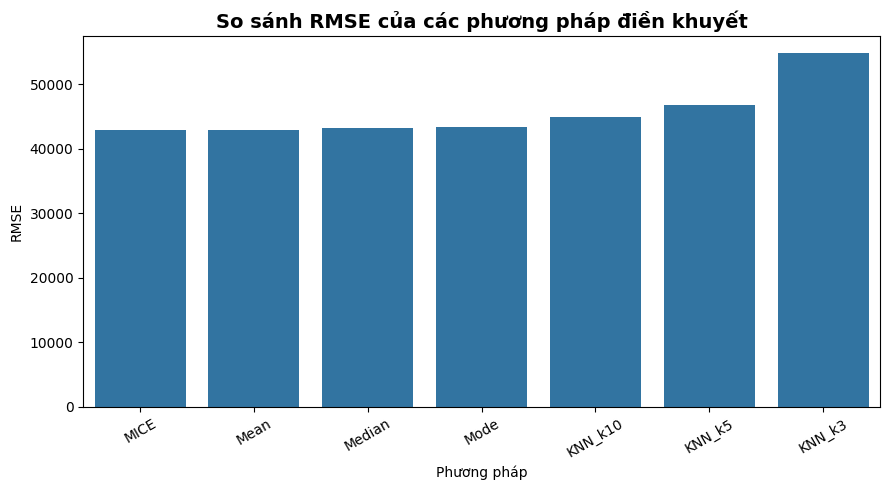

In [9]:
plt.figure(figsize=(9, 5))
sns.barplot(data=imputation_results, x="method", y="rmse")
plt.title("So sánh RMSE của các phương pháp điền khuyết", fontsize=14, fontweight="bold")
plt.xlabel("Phương pháp")
plt.ylabel("RMSE")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Nhận xét**
- Dựa trên kết quả thực nghiệm với 10% dữ liệu thiếu giả lập (MCAR), phương pháp **MICE** đạt hiệu quả tốt nhất với RMSE thấp nhất (~42973.53).
- Các phương pháp **Mean**, **Median** và **Mode** xếp ngay sau với sai số chênh lệch không đáng kể, cho thấy khả năng ước lượng trung tâm khá ổn định, tuy nhiên vẫn kém hơn so với MICE do không tận dụng được mối quan hệ giữa các biến.
- Ngược lại, các phương pháp dựa trên khoảng cách như **k-NN** cho kết quả kém hơn đáng kể, cho thấy chúng không phù hợp với đặc điểm phân phối và mức độ biến thiên của các thuộc tính số trong tập dữ liệu này.

### 1.3 Kết luận

In [10]:
print("========== KẾT LUẬN CHIẾN LƯỢC ĐIỀN KHUYẾT ==========")
best_imputation_method = imputation_results.iloc[0]["method"]
best_imputation_rmse = imputation_results.iloc[0]["rmse"]

print("- Phương pháp có RMSE thấp nhất:", best_imputation_method)
print("- Giá trị RMSE thấp nhất:", round(best_imputation_rmse, 4))

========== KẾT LUẬN CHIẾN LƯỢC ĐIỀN KHUYẾT ==========
- Phương pháp có RMSE thấp nhất: MICE
- Giá trị RMSE thấp nhất: 42973.5293


Dựa trên thí nghiệm giả lập MCAR trên biến số, MICE là phương pháp cho kết quả tốt nhất và được xem là lựa chọn phù hợp nhất nếu cần điền khuyết dữ liệu số.

Vì phương pháp này không chỉ đạt sai số thấp nhất mà còn có khả năng khai thác mối quan hệ giữa các biến, giúp tái tạo dữ liệu một cách chính xác và hợp lý hơn.

Việc sử dụng MICE giúp bảo toàn tốt hơn cấu trúc phụ thuộc giữa các biến so với các phương pháp điền khuyết độc lập, từ đó cải thiện chất lượng dữ liệu đầu vào cho các bước mô hình hóa tiếp theo.

### Xử lý giá trị thiếu cho biến phân loại

Dựa trên kết quả kiểm định Chi-square trên biến chỉ báo thiếu được trình bày trong notebook `03_EDA_tabular.ipynb`, cơ chế thiếu dữ liệu của các biến phân loại **không phù hợp với giả định MCAR**, mà hợp lý hơn với cơ chế **MAR (Missing At Random)**.

Cụ thể:

- `workclass` không cho thấy sự phụ thuộc có ý nghĩa thống kê vào hai biến phân loại còn lại.  
- `occupation` có phụ thuộc vào `workclass`.  
- `native.country` có phụ thuộc vào cả `workclass` và `occupation`.  

Dựa trên kết quả này, nhóm áp dụng chiến lược điền khuyết theo **mode có điều kiện theo nhóm** nhằm phản ánh mối quan hệ giữa các biến:

- `workclass`: điền theo mode trong từng nhóm `education`  
- `occupation`: điền theo mode trong từng nhóm `workclass`  
- `native.country`: điền theo mode trong từng nhóm `workclass` và `occupation`  

Cách tiếp cận này giúp việc điền khuyết phản ánh tốt hơn cấu trúc phụ thuộc giữa các biến, thay vì sử dụng mode toàn cục một cách đơn giản.

In [11]:
df_process = df.copy()

print("Kích thước dữ liệu gốc:", df_process.shape)
print("\nSố lượng giá trị thiếu trước khi xử lý:")
display(df_process.isna().sum())

Kích thước dữ liệu gốc: (32561, 15)

Số lượng giá trị thiếu trước khi xử lý:


age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64

In [12]:
df_process["workclass"] = (
    df_process.groupby("education")["workclass"]
    .transform(lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else "Missing"))
)

df_process["occupation"] = (
    df_process.groupby("workclass")["occupation"]
    .transform(lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else "Missing"))
)

df_process["native.country"] = (
    df_process.groupby(["workclass", "occupation"])["native.country"]
    .transform(lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else "Missing"))
)

print("Số lượng giá trị thiếu sau khi xử lý biến phân loại:")
display(df_process.isna().sum())

Số lượng giá trị thiếu sau khi xử lý biến phân loại:


age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

## 2. Phát hiện và xử lý ngoại lai bằng nhiều kỹ thuật

### Mục tiêu
Ngoại lai (outliers) là các quan sát có giá trị khác biệt đáng kể so với phần lớn dữ liệu. Sự tồn tại của outliers có thể:

- Làm lệch các thống kê mô tả (mean, variance)
- Gây ảnh hưởng tiêu cực đến mô hình (đặc biệt là các mô hình tuyến tính và distance-based)
- Làm giảm khả năng tổng quát hóa của mô hình

Do đó, việc phát hiện và xử lý ngoại lai là một bước quan trọng trong pipeline tiền xử lý dữ liệu.

---

### Các phương pháp phát hiện ngoại lai

#### 1. Phương pháp thống kê: IQR và Z-score

**a) IQR (Interquartile Range)**

IQR đo khoảng giữa hai tứ phân vị:

$$
IQR = Q3 - Q1
$$

Cận dưới (Lower Bound):
$$
LB = Q_1 - 1.5 \times IQR
$$

Cận trên (Upper Bound):
$$
UB = Q_3 + 1.5 \times IQR
$$

Một điểm được xem là ngoại lai nếu:

$$
x < LB \quad \text{hoặc} \quad x > UB
$$

Ưu điểm:
- Không yêu cầu phân phối chuẩn
- Ít nhạy với outlier hơn so với mean-based methods

**b) Z-score**

Z-score đo khoảng cách của một điểm so với trung bình theo đơn vị độ lệch chuẩn:

$$
z = \frac{x - \mu}{\sigma}
$$

Trong đó:
- $\mu$: trung bình
- $\sigma$: độ lệch chuẩn

Một điểm thường được xem là ngoại lai nếu:

$$
|z| > 3
$$

Nhược điểm:
- Nhạy với outliers
- Giả định dữ liệu gần phân phối chuẩn

---

#### 2. Isolation Forest

Isolation Forest là phương pháp dựa trên cây (tree-based), hoạt động dựa trên nguyên lý:

> Ngoại lai là các điểm dễ bị cô lập hơn so với các điểm bình thường.

Thuật toán xây dựng nhiều cây phân hoạch ngẫu nhiên. Độ sâu trung bình để cô lập một điểm được dùng làm chỉ số.

Điểm bất thường (Anomaly Score) $s(x, n)$ được tính:

$$
s(x, n) = 2^{-\frac{E(h(x))}{c(n)}}
$$

Trong đó:
- $E(h(x))$: kỳ vọng độ dài đường đi
- $c(n)$: hệ số chuẩn hóa

Diễn giải:
- $s \approx 1$ → ngoại lai  
- $s \ll 0.5$ → bình thường  

Giá trị anomaly score được so sánh với một ngưỡng (phụ thuộc vào tham số contamination) để phân loại điểm là ngoại lai hay bình thường.

Hyperparameter:
- `contamination ∈ {0.01, 0.05, 0.1}`

Ưu điểm:
- Không giả định phân phối
- Hiệu quả với dữ liệu lớn và nhiều chiều

---

#### 3. Local Outlier Factor (LOF)

LOF đo mức độ "cô lập cục bộ" của một điểm dựa trên mật độ lân cận.

$$
LOF_k(x) = \frac{\sum_{o \in N_k(x)} \frac{lrd_k(o)}{lrd_k(x)}}{|N_k(x)|}
$$

Trong đó:
- $N_k(x)$: tập k láng giềng
- $lrd_k(x)$: mật độ lân cận

Diễn giải:
- $LOF \approx 1$ → bình thường  
- $LOF > 1$ → mật độ thấp → ngoại lai  

LOF đặc biệt hiệu quả trong việc phát hiện các ngoại lai cục bộ (local anomalies), tức là các điểm có mật độ thấp so với lân cận nhưng không nhất thiết là ngoại lai toàn cục.

Hyperparameter:
- `n_neighbors ∈ {10, 20, 50}`

Ưu điểm:
- Phát hiện tốt outlier cục bộ
- Không yêu cầu phân phối

---

#### 4. DBSCAN (Density-Based Spatial Clustering)

DBSCAN là thuật toán gom cụm dựa trên mật độ.

Một điểm $x$ là điểm lõi nếu:

$$
|N_{\epsilon}(x)| \geq MinPts
$$

Trong đó:
$$
N_{\epsilon}(x) = \{y \in D \mid dist(x, y) \leq \epsilon\}
$$

Các điểm không thuộc cụm nào (label = -1) được xem là ngoại lai.

Cơ chế:
> Điểm không đạt mật độ và không thể tiếp cận từ điểm lõi → ngoại lai

Hyperparameter:
- $\epsilon$: bán kính
- `min_samples`: số điểm tối thiểu

Ưu điểm:
- Không cần xác định số cụm
- Phát hiện tốt outlier phi tuyến

Lưu ý:  
Do DBSCAN dựa trên khoảng cách, các thuộc tính số cần được chuẩn hóa trước khi áp dụng để tránh hiện tượng một số biến có giá trị lớn chi phối kết quả.

---

### Tiêu chí đánh giá và so sánh các kỹ thuật

Để lựa chọn phương pháp xử lý ngoại lai tối ưu, nhóm thực hiện các phân tích định lượng sau:

**1. Phân tích sự chồng chéo (Overlap Analysis)**  
Sử dụng **Jaccard Similarity**:

$$
J(A, B) = \frac{|A \cap B|}{|A \cup B|}
$$

để đo mức độ tương đồng giữa các tập ngoại lai.

---

**2. Đánh giá tác động phân phối**  
Sử dụng **Kolmogorov-Smirnov (KS test)** để so sánh phân phối trước và sau khi loại bỏ ngoại lai.

- $p < 0.05$ → phân phối thay đổi có ý nghĩa  
- $p ≥ 0.05$ → không đủ bằng chứng thay đổi  

---

**3. Định lượng mức độ nhiễm (Contamination)**  
Báo cáo tỷ lệ dữ liệu bị xem là ngoại lai theo từng phương pháp và từng cấu hình hyperparameter.

---

Các tiêu chí trên được kết hợp nhằm đánh giá toàn diện hiệu quả của từng phương pháp, từ đó lựa chọn phương pháp phù hợp nhất với đặc điểm dữ liệu.

Do mỗi phương pháp dựa trên các giả định khác nhau (phân phối, mật độ, khoảng cách), tập ngoại lai phát hiện được có thể khác nhau đáng kể. Vì vậy, việc so sánh đa phương pháp là cần thiết để tránh bias từ một phương pháp đơn lẻ.

### 2.1 Thiết lập dữ liệu và phát hiện ngoại lai

In [13]:
# Chỉ lấy các thuộc tính số
X_num = df_process[numeric_cols].copy()

print("Kích thước dữ liệu số:", X_num.shape)
print("\nSố giá trị thiếu trong từng cột số:")
display(X_num.isna().sum())

display(X_num.head())

Kích thước dữ liệu số: (32561, 6)

Số giá trị thiếu trong từng cột số:


age               0
fnlwgt            0
education.num     0
capital.gain      0
capital.loss      0
hours.per.week    0
dtype: int64

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
0,90,77053,9,0,4356,40
1,82,132870,9,0,4356,18
2,66,186061,10,0,4356,40
3,54,140359,4,0,3900,40
4,41,264663,10,0,3900,40


In [45]:
def detect_outliers_iqr(data, multiplier=1.5):
    mask = pd.Series(False, index=data.index)
    for col in data.columns:
        q1 = data[col].quantile(0.25)
        q3 = data[col].quantile(0.75)
        iqr = q3 - q1
        mask |= (data[col] < q1 - multiplier*iqr) | (data[col] > q3 + multiplier*iqr)
    return set(data.index[mask])

def detect_outliers_zscore(data, threshold=3.0):
    z = np.abs(stats.zscore(data, nan_policy="omit"))
    return set(data.index[(z > threshold).any(axis=1)])

outlier_sets = {}

# IQR + Z
outlier_sets["IQR"] = detect_outliers_iqr(X_num)
outlier_sets["Z-score"] = detect_outliers_zscore(X_num)

# Isolation Forest với nhiều contamination
for cont in [0.01, 0.05, 0.1]:
    iso = IsolationForest(contamination=cont, random_state=42)
    pred = iso.fit_predict(X_num)
    outlier_sets[f"IsolationForest_{cont}"] = set(X_num.index[pred == -1])

# LOF với nhiều n_neighbors
for nn in [10, 20, 50]:
    lof = LocalOutlierFactor(n_neighbors=nn)
    pred = lof.fit_predict(X_num)
    outlier_sets[f"LOF_{nn}"] = set(X_num.index[pred == -1])

# DBSCAN (cần scale trước vì dựa trên khoảng cách)
scaled_for_dbscan = StandardScaler().fit_transform(X_num)

for eps in [1.5, 2.0, 2.5]:
    db = DBSCAN(eps=eps, min_samples=10)
    db_labels = db.fit_predict(scaled_for_dbscan)
    outlier_sets[f"DBSCAN_eps{eps}"] = set(X_num.index[db_labels == -1])

print("Các phương pháp/cấu hình đã chạy:")
for method in outlier_sets.keys():
    print("-", method)

MemoryError: bad allocation

### 2.2 So sánh các phương pháp phát hiện ngoại lai

In [15]:
def jaccard(a, b):
    return len(a & b) / len(a | b) if len(a | b) else np.nan

# Ratio
ratio_df = pd.DataFrame([
    {"method": k, "ratio (%)": len(v)/len(X_num)*100}
    for k, v in outlier_sets.items()
]).sort_values("ratio (%)", ascending=False)

print("Tỷ lệ dữ liệu bị xem là ngoại lai:")
display(ratio_df)

# Jaccard matrix
methods = list(outlier_sets.keys())
jaccard_mat = pd.DataFrame(index=methods, columns=methods)

for m1 in methods:
    for m2 in methods:
        jaccard_mat.loc[m1, m2] = jaccard(outlier_sets[m1], outlier_sets[m2])

print("\nMa trận Jaccard similarity:")
display(jaccard_mat.astype(float).round(3))

Tỷ lệ dữ liệu bị xem là ngoại lai:


,method,ratio (%)
0,IQR,41.657197
4,IsolationForest_0.1,9.999693
7,LOF_50,8.593102
1,Z-score,8.393477
3,IsolationForest_0.05,4.999846
6,LOF_20,4.791008
5,LOF_10,4.625165
2,IsolationForest_0.01,1.001198
8,DBSCAN_eps1.5,0.304045
9,DBSCAN_eps2.0,0.085992



Ma trận Jaccard similarity:


,IQR,Z-score,IsolationForest_0.01,IsolationForest_0.05,IsolationForest_0.1,LOF_10,LOF_20,LOF_50,DBSCAN_eps1.5,DBSCAN_eps2.0
IQR,1.000,0.201,0.024,0.120,0.239,0.081,0.109,0.206,0.007,0.002
Z-score,0.201,1.000,0.114,0.450,0.586,0.133,0.242,0.392,0.032,0.010
IsolationForest_0.01,0.024,0.114,1.000,0.200,0.100,0.034,0.057,0.061,0.164,0.050
IsolationForest_0.05,0.120,0.450,0.200,1.000,0.500,0.148,0.253,0.325,0.052,0.016
IsolationForest_0.1,0.239,0.586,0.100,0.500,1.000,0.146,0.244,0.415,0.029,0.009
LOF_10,0.081,0.133,0.034,0.148,0.146,1.000,0.363,0.185,0.028,0.012
LOF_20,0.109,0.242,0.057,0.253,0.244,0.363,1.000,0.445,0.034,0.011
LOF_50,0.206,0.392,0.061,0.325,0.415,0.185,0.445,1.000,0.027,0.009
DBSCAN_eps1.5,0.007,0.032,0.164,0.052,0.029,0.028,0.034,0.027,1.000,0.283
DBSCAN_eps2.0,0.002,0.010,0.050,0.016,0.009,0.012,0.011,0.009,0.283,1.000


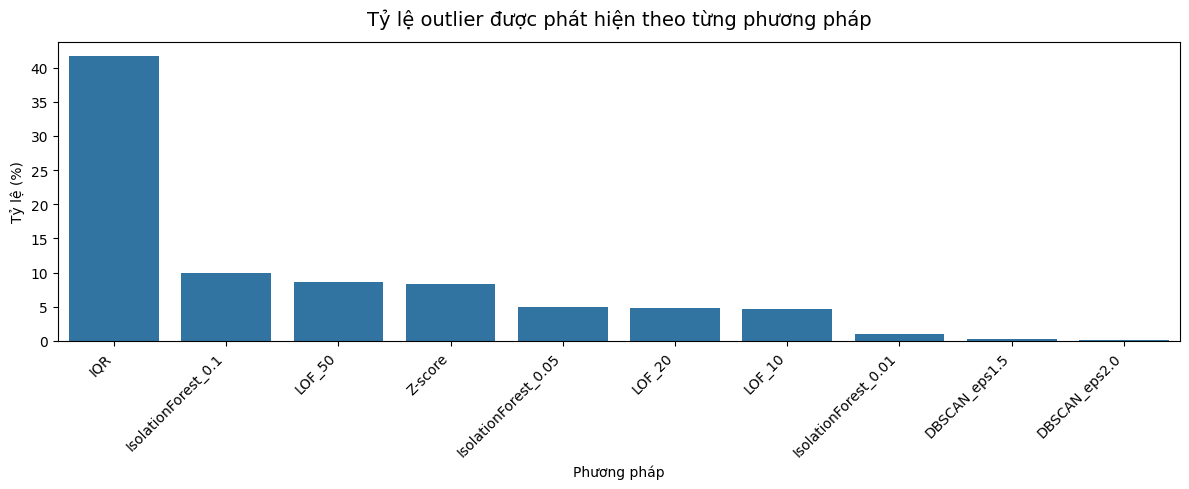

In [16]:
plt.figure(figsize=(12, 5))
sns.barplot(data=ratio_df, x="method", y="ratio (%)")
plt.title("Tỷ lệ outlier được phát hiện theo từng phương pháp", fontsize=14, pad=12)
plt.xlabel("Phương pháp")
plt.ylabel("Tỷ lệ (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

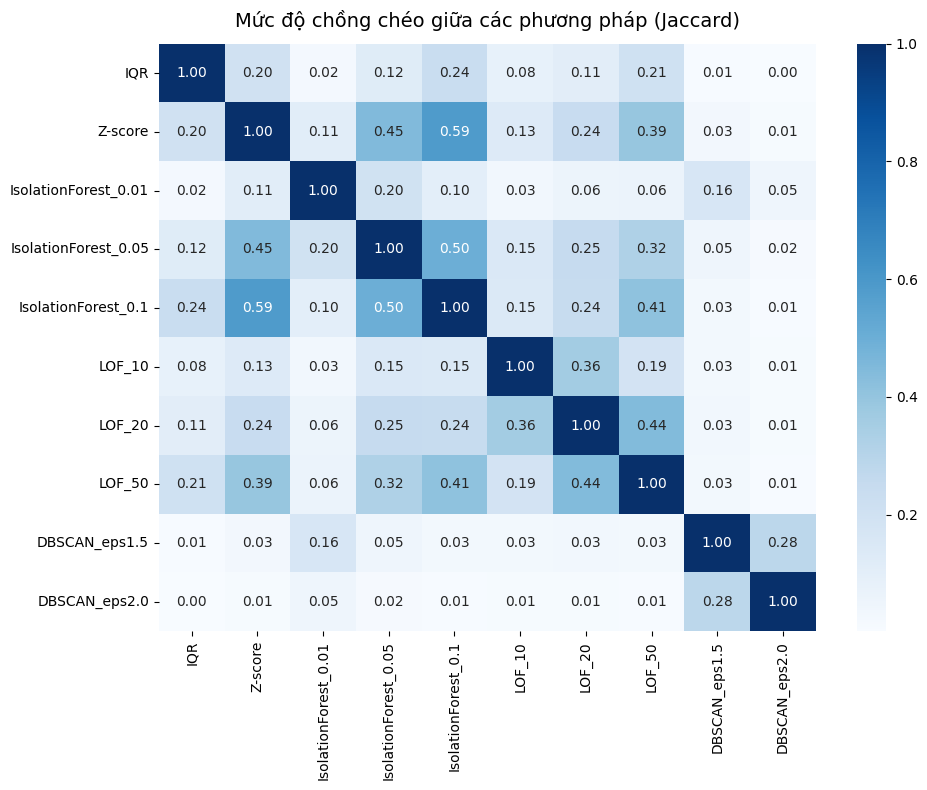

In [17]:
plt.figure(figsize=(10, 8))
sns.heatmap(jaccard_mat.astype(float), annot=True, fmt=".2f", cmap="Blues")
plt.title("Mức độ chồng chéo giữa các phương pháp (Jaccard)", fontsize=14, pad=12)
plt.tight_layout()
plt.show()

**Nhận xét**

Kết quả cho thấy các phương pháp phát hiện ngoại lai cho ra tỷ lệ rất khác nhau. Cụ thể:

- **IQR** phát hiện tỷ lệ ngoại lai cao nhất (~41.66%), cho thấy đây là phương pháp rất nhạy và có xu hướng gắn nhãn nhiều quan sát là ngoại lai khi kết hợp trên nhiều thuộc tính số.
- **Isolation Forest** và **LOF** cho kết quả ở mức trung gian, dao động khoảng 1% đến gần 10%, phản ánh khả năng cân bằng hơn giữa việc phát hiện ngoại lai và bảo toàn dữ liệu.
- **DBSCAN** cho tỷ lệ thấp nhất (dưới 0.5%), cho thấy phương pháp này rất bảo thủ và chỉ nhận diện một số ít điểm thực sự tách biệt về mặt mật độ.

Ma trận **Jaccard similarity** cũng cho thấy mức độ chồng chéo giữa các phương pháp nhìn chung không cao. Phần lớn các giá trị nằm ở mức thấp đến trung bình, chứng tỏ mỗi thuật toán đang phát hiện những kiểu ngoại lai khác nhau.  

Một số cặp phương pháp có mức độ tương đồng cao hơn, chẳng hạn:
- **Z-score** và **IsolationForest_0.1** (Jaccard ≈ 0.59)
- **DBSCAN_eps2.0** và **DBSCAN_eps2.5** (Jaccard ≈ 0.57)
- **IsolationForest_0.05** và **IsolationForest_0.1** (Jaccard ≈ 0.50)

Điều này cho thấy các cấu hình gần nhau trong cùng một họ phương pháp có xu hướng phát hiện tập ngoại lai tương tự, trong khi các họ phương pháp khác nhau (ví dụ IQR và DBSCAN) lại có rất ít chồng chéo.

Nhìn chung, kết quả này xác nhận rằng **không tồn tại một định nghĩa ngoại lai duy nhất cho toàn bộ dữ liệu**, do đó việc so sánh đa phương pháp là cần thiết trước khi đưa ra quyết định xử lý.

### 2.3 Đánh giá tác động và lựa chọn phương pháp
Sau khi so sánh số lượng và mức độ chồng chéo của các tập ngoại lai, nhóm tiếp tục đánh giá **tác động của việc loại bỏ ngoại lai đến phân phối dữ liệu** bằng **kiểm định Kolmogorov–Smirnov (KS test)**.

Mục tiêu của bước này là trả lời câu hỏi quan trọng:  
> Một phương pháp phát hiện được nhiều ngoại lai hơn chưa chắc đã tốt hơn, nếu việc loại bỏ đó làm thay đổi mạnh cấu trúc phân phối của dữ liệu.

Vì vậy, việc lựa chọn phương pháp cuối cùng được thực hiện dựa trên **sự cân bằng** giữa:
- tỷ lệ ngoại lai được loại bỏ
- mức độ bảo toàn phân phối dữ liệu

In [18]:
ks_results = []

for method, idx_set in outlier_sets.items():
    keep_mask = ~X_num.index.isin(idx_set)

    for col in X_num.columns:
        original_data = X_num[col]
        cleaned_data = X_num.loc[keep_mask, col]

        ks_stat, p_value = ks_2samp(original_data, cleaned_data)

        ks_results.append({
            "method": method,
            "feature": col,
            "ks_stat": ks_stat,
            "p_value": p_value,
            "distribution_changed": "Yes" if p_value < 0.05 else "No"
        })

ks_results_df = pd.DataFrame(ks_results).sort_values(
    ["feature", "p_value"],
    ascending=[True, True]
).reset_index(drop=True)

print("Kết quả KS test chi tiết theo từng thuộc tính:")
display(ks_results_df)

Kết quả KS test chi tiết theo từng thuộc tính:


,method,feature,ks_stat,p_value,distribution_changed
0,IQR,age,0.035591,1.223465e-13,Yes
1,IsolationForest_0.1,age,0.021728,9.314595e-07,Yes
2,LOF_50,age,0.011998,2.254642e-02,Yes
3,IsolationForest_0.05,age,0.011692,2.594793e-02,Yes
4,Z-score,age,0.010908,4.887336e-02,Yes
5,LOF_10,age,0.004234,9.369313e-01,No
6,LOF_20,age,0.003941,9.652029e-01,No
7,IsolationForest_0.01,age,0.003506,9.881746e-01,No
8,DBSCAN_eps1.5,age,0.000925,1.000000e+00,No
9,DBSCAN_eps2.0,age,0.000195,1.000000e+00,No


In [19]:
ks_summary_df = (
    ks_results_df.groupby("method")
    .agg(
        avg_ks_stat=("ks_stat", "mean"),
        min_p_value=("p_value", "min"),
        n_features_changed=("distribution_changed", lambda x: (x == "Yes").sum())
    )
    .sort_values("avg_ks_stat")
    .reset_index()
)

print("\nTóm tắt KS test theo từng phương pháp:")
display(ks_summary_df)


Tóm tắt KS test theo từng phương pháp:


,method,avg_ks_stat,min_p_value,n_features_changed
0,DBSCAN_eps2.0,0.000262,1.000000e+00,0
1,DBSCAN_eps1.5,0.000896,1.000000e+00,0
2,IsolationForest_0.01,0.003578,6.710433e-01,0
3,LOF_10,0.006296,6.164856e-02,0
4,LOF_20,0.010068,3.130685e-07,2
5,IsolationForest_0.05,0.013568,4.516458e-11,5
6,Z-score,0.016086,5.213955e-28,3
7,LOF_50,0.019614,1.719468e-26,3
8,IsolationForest_0.1,0.022845,1.037223e-27,5
9,IQR,0.067802,1.874391e-301,6


**Nhận xét**

Kết quả KS test cho thấy mức độ ảnh hưởng đến phân phối dữ liệu của các phương pháp là rất khác nhau.

- **DBSCAN** có giá trị `avg_ks_stat` thấp nhất, đồng thời không có thuộc tính nào thay đổi phân phối ở mức ý nghĩa thống kê. Tuy nhiên, phương pháp này chỉ phát hiện một tỷ lệ ngoại lai rất thấp (< 1%), do đó chưa thực sự hiệu quả về mặt xử lý.
- **IQR** có `avg_ks_stat` cao nhất và làm thay đổi phân phối của toàn bộ 6 thuộc tính số. Điều này phù hợp với việc IQR loại bỏ quá nhiều quan sát (~41.66%), dẫn đến nguy cơ mất mát thông tin đáng kể.
- Các phương pháp như **Isolation Forest** và **LOF** nằm ở khoảng giữa, thể hiện sự đánh đổi hợp lý hơn giữa khả năng loại bỏ ngoại lai và mức độ bảo toàn phân phối.

Nếu chỉ xét duy nhất KS statistic, DBSCAN sẽ là phương pháp tốt nhất. Tuy nhiên, cách tiếp cận này có thể thiên lệch về phía những phương pháp quá bảo thủ và gần như không loại bỏ dữ liệu. Vì vậy, nhóm bổ sung thêm tiêu chí tỷ lệ ngoại lai hợp lý (1%–15%) để đảm bảo phương pháp được chọn vừa có tác dụng xử lý, vừa không làm méo dữ liệu quá mức.

In [20]:
# Thiết lập ngưỡng lọc
MIN_RATIO = 1.0  # Loại ít nhất 1% để thực sự có xử lý
MAX_RATIO = 15.0 # Không loại quá 15% để tránh mất dữ liệu quá nhiều

# Kết hợp bảng Ratio và bảng KS để lọc
selection_df = ks_summary_df.merge(ratio_df, on="method")

# Bước 1: Lọc các phương pháp nằm trong khoảng tỷ lệ cho phép
candidates = selection_df[
    (selection_df["ratio (%)"] >= MIN_RATIO) &
    (selection_df["ratio (%)"] <= MAX_RATIO)
].reset_index(drop=True)

# Bước 2: Trong các ứng viên, chọn cái có avg_ks_stat thấp nhất
if not candidates.empty:
    best_method = candidates.sort_values("avg_ks_stat").iloc[0]["method"]
else:
    # Nếu không có cái nào nằm trong khoảng 1-15%, chọn cái gần nhất với ngưỡng 5%
    best_method = selection_df.iloc[(selection_df['ratio (%)']-5).abs().argsort()[:1]]["method"].values[0]

print(f"Phương pháp được chọn tự động dựa trên tiêu chí (Ratio 1-15% & Min KS): {best_method}")

out_idx = outlier_sets[best_method]
X_clean = X_num.loc[~X_num.index.isin(out_idx)]

print("\nKích thước dữ liệu:")
print("Trước khi loại ngoại lai:", X_num.shape)
print("Sau khi loại ngoại lai:", X_clean.shape)
print("Số dòng bị loại:", len(out_idx))

Phương pháp được chọn tự động dựa trên tiêu chí (Ratio 1-15% & Min KS): IsolationForest_0.01

Kích thước dữ liệu:
Trước khi loại ngoại lai: (32561, 6)
Sau khi loại ngoại lai: (32235, 6)
Số dòng bị loại: 326


**Nhận xét**

Sau khi kết hợp hai tiêu chí:
- tỷ lệ ngoại lai nằm trong khoảng hợp lý **1%-15%**
- giá trị **KS statistic trung bình thấp nhất**

phương pháp được lựa chọn là **IsolationForest_0.01**.

Kết quả này cho thấy **Isolation Forest với contamination = 0.01** là phương án cân bằng tốt nhất trong số các ứng viên:
- phát hiện khoảng **1.00%** dữ liệu là ngoại lai
- chỉ loại bỏ **326 quan sát** trên tổng số **32,561**
- đồng thời duy trì mức thay đổi phân phối rất thấp (`avg_ks_stat ≈ 0.0036`)

Nói cách khác, phương pháp này giúp loại bỏ các ngoại lai rõ rệt nhất mà vẫn bảo toàn gần như nguyên vẹn cấu trúc phân phối của dữ liệu. Đây là lựa chọn phù hợp hơn so với:
- **DBSCAN**: vốn quá bảo thủ và loại bỏ quá ít dữ liệu
- **IQR**: vốn quá nhạy và loại bỏ quá nhiều dữ liệu

Biểu đồ boxplot trên biến `fnlwgt` được sử dụng để minh họa sự thay đổi phân phối, do đây là thuộc tính có độ phân tán lớn và nhiều giá trị cực trị.

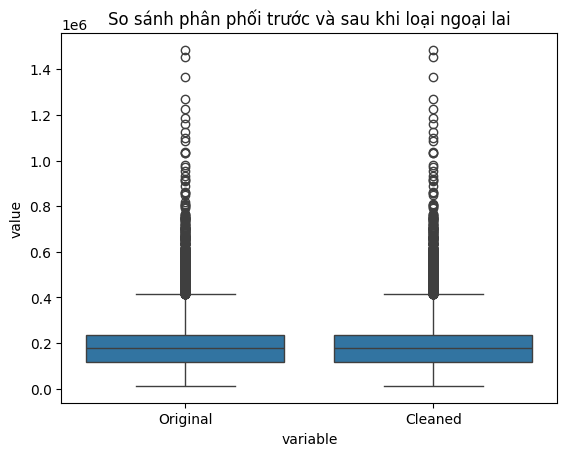

In [21]:
col = "fnlwgt"

df_plot = pd.DataFrame({
    "Original": X_num[col],
    "Cleaned": X_clean[col].reindex(X_num.index)
}).melt()

sns.boxplot(data=df_plot, x="variable", y="value")
plt.title("So sánh phân phối trước và sau khi loại ngoại lai")
plt.show()

**Nhận xét**

Biểu đồ boxplot giữa phân phối trước và sau khi loại ngoại lai cho thấy sự khác biệt không quá lớn. Điều này là hợp lý vì phương pháp được chọn (**IsolationForest_0.01**) chỉ loại bỏ khoảng 1% quan sát, chủ yếu là các ngoại lai cực đoan nhất.

Median, khoảng tứ phân vị (IQR) và hình dạng tổng thể của phân phối gần như được giữ nguyên, cho thấy phương pháp này bảo toàn tốt cấu trúc dữ liệu. Tuy nhiên, một số điểm cực trị vẫn còn xuất hiện trên biểu đồ, phản ánh rằng cách tiếp cận được chọn là **bảo thủ có kiểm soát**: loại bỏ các ngoại lai mạnh nhất, thay vì cố gắng triệt tiêu toàn bộ mọi điểm bất thường.

Điều này phù hợp với mục tiêu của bài toán, trong đó việc giữ được đặc trưng tự nhiên của dữ liệu quan trọng hơn so với việc làm sạch quá mức.

### Kết luận

Từ các phân tích trên, có thể rút ra ba nhận định chính:

- Các phương pháp phát hiện ngoại lai cho kết quả rất khác nhau cả về số lượng lẫn tập quan sát được gắn nhãn, cho thấy ngoại lai là một khái niệm phụ thuộc mạnh vào giả định của từng thuật toán.
- Những phương pháp quá nhạy như **IQR** có nguy cơ loại bỏ quá nhiều dữ liệu và làm thay đổi mạnh phân phối, trong khi những phương pháp quá bảo thủ như **DBSCAN** lại không thực sự xử lý được nhiều ngoại lai.
- **IsolationForest_0.01** là lựa chọn phù hợp nhất cho pipeline chính vì cân bằng tốt giữa khả năng loại bỏ ngoại lai và bảo toàn cấu trúc phân phối dữ liệu.

Do đó, nhóm sử dụng tập dữ liệu sau khi loại ngoại lai bằng **IsolationForest_0.01** làm đầu vào cho các bước tiền xử lý tiếp theo.

## 3. Chuẩn hóa dữ liệu có kiểm định

### Mục tiêu

Sau khi xử lý giá trị thiếu và loại bỏ ngoại lai, các thuộc tính số vẫn có thể tồn tại sự khác biệt lớn về thang đo (scale) và phân phối. Điều này có thể gây ảnh hưởng tiêu cực đến các mô hình học máy, đặc biệt là:

- Các mô hình dựa trên khoảng cách (k-NN, SVM, clustering)
- Các mô hình tuyến tính (Logistic Regression)
- Các thuật toán nhạy với phương sai

Do đó, bước chuẩn hóa dữ liệu nhằm:
- Đưa các biến về cùng thang đo
- Giảm ảnh hưởng của outliers còn lại
- Cải thiện khả năng hội tụ và hiệu suất mô hình

---

### Các phương pháp chuẩn hóa

Nhóm tiến hành so sánh nhiều phương pháp chuẩn hóa phổ biến nhằm đánh giá tác động đến phân phối dữ liệu và lựa chọn phương pháp phù hợp.

---

#### 1. Min-Max Scaling

Phương pháp này đưa dữ liệu về khoảng $[0, 1]$ theo công thức:

$$
x' = \frac{x - x_{\min}}{x_{\max} - x_{\min}}
$$

**Đặc điểm:**
- Giữ nguyên hình dạng phân phối
- Nhạy với outliers (do phụ thuộc vào min/max)

---

#### 2. Z-score Standardization

Chuẩn hóa dữ liệu về phân phối có trung bình bằng 0 và độ lệch chuẩn bằng 1:

$$
z = \frac{x - \mu}{\sigma}
$$

Trong đó:
- $\mu$: trung bình  
- $\sigma$: độ lệch chuẩn  

**Đặc điểm:**
- Phù hợp với dữ liệu gần phân phối chuẩn
- Nhạy với outliers

---

#### 3. Robust Scaling

Sử dụng median và IQR để giảm ảnh hưởng của outliers:

$$
x' = \frac{x - \text{median}}{IQR}
$$

Trong đó:

$$
IQR = Q3 - Q1
$$

**Đặc điểm:**
- Ít nhạy với outliers
- Phù hợp với dữ liệu lệch (skewed)

---

#### 4. Quantile Transform

Biến đổi phân phối dữ liệu thành phân phối mong muốn thông qua hàm phân vị.

- **Uniform output**:

$$
x' \sim U(0,1)
$$

- **Normal output**:

$$
x' \sim \mathcal{N}(0,1)
$$

**Đặc điểm:**
- Làm thay đổi hoàn toàn hình dạng phân phối
- Giảm ảnh hưởng của outliers
- Có thể làm mất ý nghĩa khoảng cách ban đầu

---

### Phương pháp đánh giá

Để đánh giá hiệu quả của từng phương pháp chuẩn hóa, nhóm sử dụng hai hướng tiếp cận:

---

#### 1. Trực quan hóa phân phối

Sử dụng **violin plot** để quan sát:
- Hình dạng phân phối
- Mức độ lệch (skewness)
- Sự tập trung của dữ liệu

---

#### 2. Kiểm định Levene’s test (Homoscedasticity)

Levene’s test được sử dụng để kiểm tra giả thuyết về sự đồng nhất phương sai giữa các nhóm.

- **Giả thuyết $H_0$**: các nhóm có phương sai bằng nhau  
- **Giả thuyết $H_1$**: có ít nhất một nhóm có phương sai khác biệt  

Nếu:

- $p < 0.05 \Rightarrow$ bác bỏ $ H_0 \Rightarrow$ không đồng nhất phương sai
- $p \ge 0.05 \Rightarrow$ không đủ bằng chứng bác bỏ $H_0$

**Ý nghĩa:**
- Phương pháp chuẩn hóa tốt nên giúp phương sai giữa các thuộc tính trở nên đồng đều hơn
- Điều này đặc biệt quan trọng với các mô hình giả định homoscedasticity

### 3.1 Thiết lập dữ liệu cho bước chuẩn hóa

In [22]:
scaling_methods = {
    "MinMax": MinMaxScaler(),
    "Z-score": StandardScaler(),
    "Robust": RobustScaler(),
    "Quantile_Uniform": QuantileTransformer(output_distribution="uniform", random_state=42),
    "Quantile_Normal": QuantileTransformer(output_distribution="normal", random_state=42)
}

scaled_data = {}

for method_name, scaler in scaling_methods.items():
    scaled_array = scaler.fit_transform(X_clean)
    scaled_data[method_name] = pd.DataFrame(
        scaled_array,
        columns=X_clean.columns,
        index=X_clean.index
    )

print("Đã áp dụng các phương pháp chuẩn hóa sau:")
for method in scaled_data.keys():
    print("-", method)

Đã áp dụng các phương pháp chuẩn hóa sau:
- MinMax
- Z-score
- Robust
- Quantile_Uniform
- Quantile_Normal


### 3.2 Kiểm định Levene đánh giá mức độ đồng nhất phương sai

Sau khi chuẩn hóa, nhóm sử dụng **Levene’s test** để kiểm tra mức độ đồng nhất phương sai giữa các thuộc tính số dưới từng phương pháp.

In [23]:
levene_results = []

for method_name, df_scaled in scaled_data.items():
    for col in numeric_cols:
        if col == target_col:
            continue

        # chia nhóm theo income
        groups = [
            df_scaled[df_process[target_col] == cls][col]
            for cls in df_process[target_col].unique()
        ]

        stat, p_value = levene(*groups)

        levene_results.append({
            "method": method_name,
            "feature": col,
            "levene_stat": stat,
            "p_value": p_value,
            "homoscedasticity": "Yes" if p_value >= 0.05 else "No"
        })

levene_results_df = pd.DataFrame(levene_results).sort_values(
    ["method", "p_value"]
).reset_index(drop=True)

print("Kết quả Levene’s test theo từng biến:")
display(levene_results_df)

Kết quả Levene’s test theo từng biến:


,method,feature,levene_stat,p_value,homoscedasticity
0,MinMax,capital.gain,3046.364095,0.000000e+00,No
1,MinMax,age,732.950593,1.253372e-159,No
2,MinMax,capital.loss,695.589050,1.112340e-151,No
3,MinMax,education.num,262.563368,8.100173e-59,No
4,MinMax,fnlwgt,16.029885,6.249005e-05,No
5,MinMax,hours.per.week,0.178713,6.724844e-01,Yes
6,Quantile_Normal,capital.gain,2248.183108,0.000000e+00,No
7,Quantile_Normal,age,1231.597822,8.113250e-265,No
8,Quantile_Normal,capital.loss,603.966935,3.789370e-132,No
9,Quantile_Normal,education.num,160.437058,1.110832e-36,No


**Nhận xét**

Kết quả kiểm định Levene cho thấy phần lớn các biến số đều có **p-value < 0.05**, do đó bác bỏ giả thuyết $H_0$ → phương sai giữa các nhóm thu nhập (**income**) là khác nhau, tức dữ liệu **không đạt homoscedasticity**.

Các biến như `capital.gain`, `capital.loss`, `age`, `education.num` có p-value rất nhỏ, cho thấy sự khác biệt phương sai rõ rệt giữa các nhóm. Biến `fnlwgt` cũng có sự khác biệt nhưng ở mức độ nhẹ hơn.  
Riêng `hours.per.week` là trường hợp đặc biệt khi **không bác bỏ $H_0$** với các phương pháp tuyến tính (MinMax, Z-score, Robust), nhưng lại mất tính đồng nhất khi áp dụng Quantile Transform.

Ngoài ra, **MinMax, Z-score và Robust cho kết quả giống nhau hoàn toàn** do đều là biến đổi tuyến tính, không làm thay đổi tỷ lệ phương sai. Ngược lại, **Quantile Transform** làm thay đổi kết quả ở một số biến, cho thấy tác động mạnh đến cấu trúc phân phối.

Nhìn chung, sự khác biệt phương sai là đặc trưng nội tại của dữ liệu và không thể loại bỏ hoàn toàn bằng các phương pháp chuẩn hóa.

### 3.3 Trực quan hóa phân phối sau chuẩn hóa bằng violin plot

Để bổ sung cho kiểm định Levene, **violin plot** được dùng nhằm quan sát trực quan phân phối của từng thuộc tính sau chuẩn hóa.

Violin plot cho phép thể hiện đồng thời:
- mật độ phân phối
- mức độ lệch
- sự tập trung của dữ liệu
- phạm vi biến thiên của từng thuộc tính

Thông qua đó, có thể đánh giá rõ hơn mức độ bảo toàn hình dạng dữ liệu và tác động của từng phương pháp chuẩn hóa.

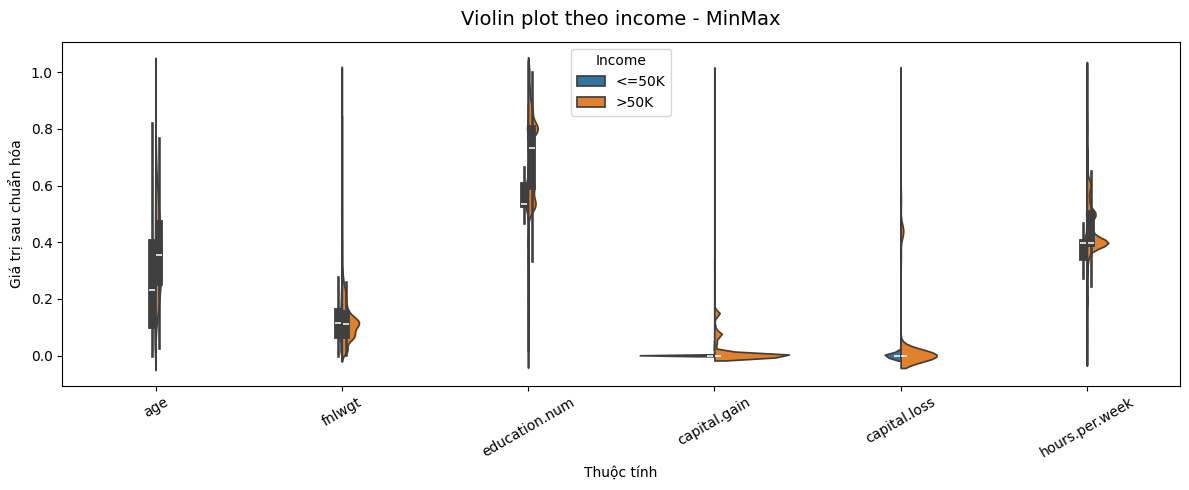

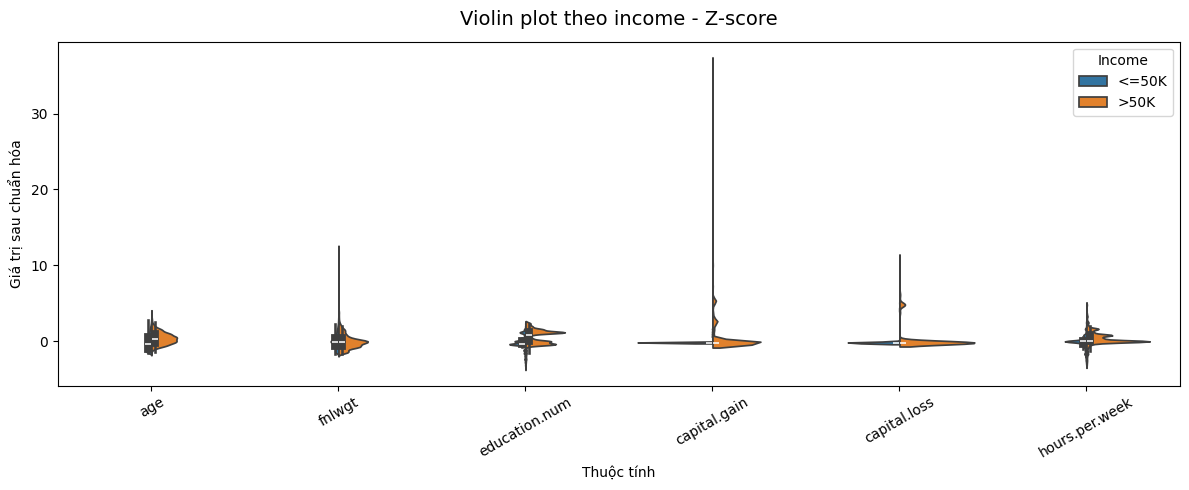

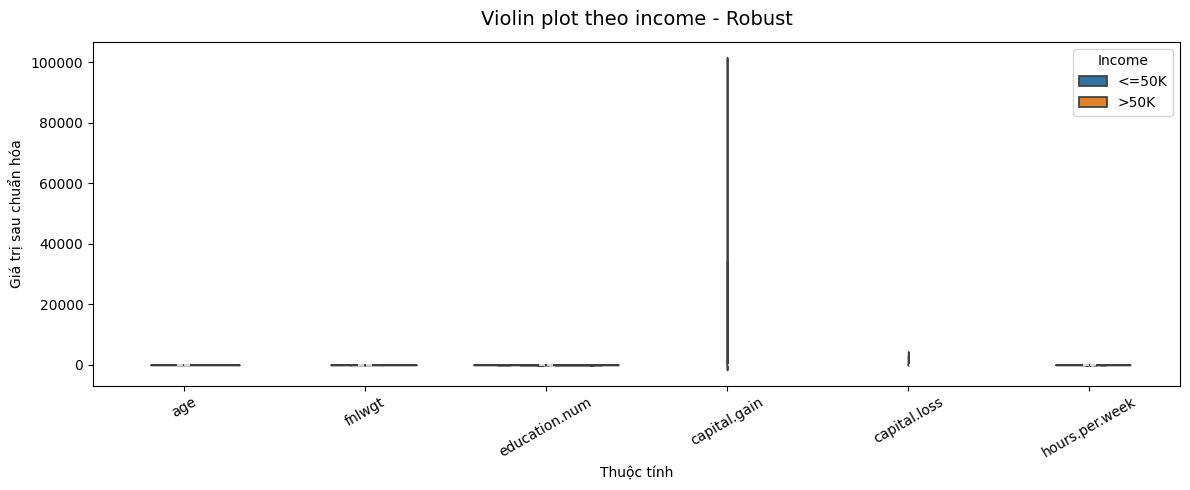

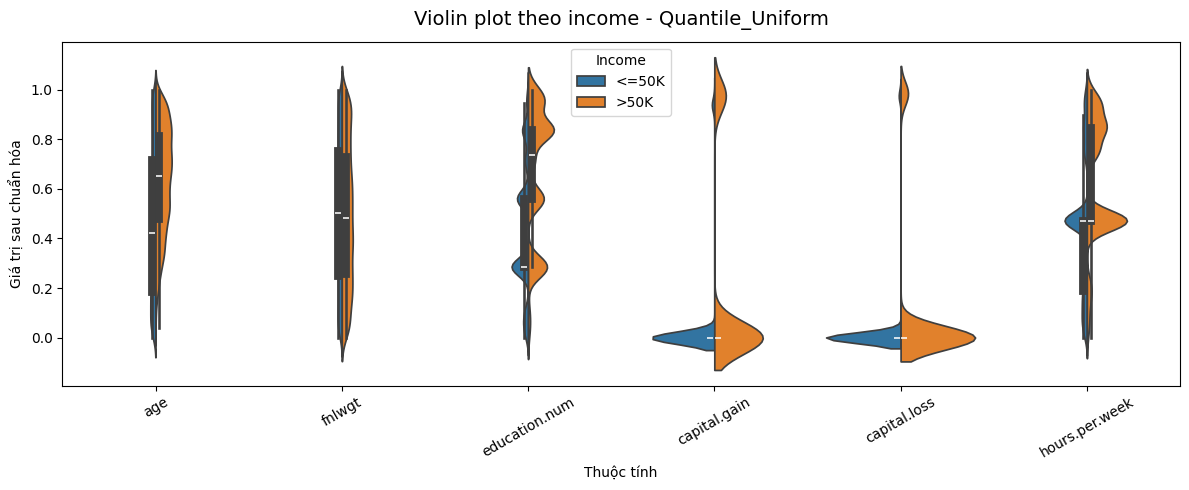

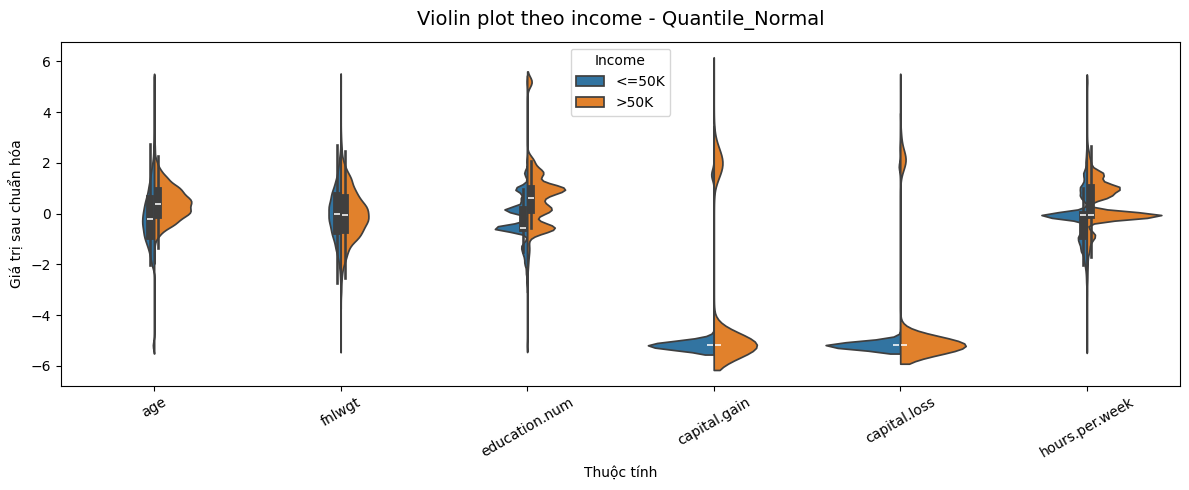

In [24]:
for method_name, df_scaled in scaled_data.items():

    # gắn lại income để so sánh theo nhóm
    df_plot = df_scaled.copy()
    df_plot["income"] = df_process[target_col]

    # reshape dữ liệu
    df_melt = df_plot.melt(
        id_vars="income",
        var_name="feature",
        value_name="value"
    )

    plt.figure(figsize=(12, 5))

    sns.violinplot(
        data=df_melt,
        x="feature",
        y="value",
        hue="income",
        split=True
    )

    plt.title(f"Violin plot theo income - {method_name}", fontsize=14, pad=12)
    plt.xlabel("Thuộc tính")
    plt.ylabel("Giá trị sau chuẩn hóa")
    plt.xticks(rotation=30)
    plt.legend(title="Income")
    plt.tight_layout()
    plt.show()

**Nhận xét**

Kết quả trực quan hóa bằng violin plot cho thấy sự khác biệt rõ rệt giữa các phương pháp chuẩn hóa về hình dạng phân phối và khả năng phân tách giữa hai nhóm thu nhập.

Các phương pháp tuyến tính như MinMax và Z-score giữ nguyên hình dạng phân phối ban đầu, do đó vẫn tồn tại hiện tượng lệch mạnh và ảnh hưởng của các giá trị ngoại lai, đặc biệt ở các biến như `capital.gain` và `capital.loss`. Điều này khiến hai nhóm `income` chồng lấn đáng kể, khó phân biệt.

Robust Scaling có cải thiện nhẹ khi giảm ảnh hưởng của ngoại lai, tuy nhiên hình dạng phân phối tổng thể vẫn không thay đổi đáng kể, và mức độ phân tách giữa các nhóm vẫn còn hạn chế.

Ngược lại, Quantile Transform (đặc biệt với output dạng normal) làm thay đổi mạnh cấu trúc phân phối, giúp dữ liệu trở nên đối xứng hơn và giảm hiện tượng lệch. Nhờ đó, sự khác biệt giữa hai nhóm income được thể hiện rõ ràng hơn ở nhiều thuộc tính, đặc biệt là `education.num` và `hours.per.week`.

Quantile Uniform cũng giúp giảm lệch nhưng vẫn còn hiện tượng nén dữ liệu ở biên, trong khi Quantile Normal cho phân phối mượt và dễ quan sát hơn.

Nhìn chung, các biểu đồ cho thấy Quantile Transform mang lại sự cải thiện rõ rệt về hình dạng phân phối và khả năng phân tách dữ liệu so với các phương pháp tuyến tính.

### Kết luận

Kết hợp giữa kiểm định Levene và trực quan hóa bằng violin plot cho thấy:

- Không có phương pháp nào giúp dữ liệu đạt được hoàn toàn tính đồng nhất phương sai (homoscedasticity), do đây là đặc trưng nội tại của dữ liệu.
- Các phương pháp tuyến tính (MinMax, Z-score, Robust) không làm thay đổi cấu trúc phân phối, do đó không cải thiện đáng kể khả năng phân tách giữa các nhóm.
- Quantile Transform, đặc biệt là dạng normal, giúp chuẩn hóa phân phối, giảm lệch và làm nổi bật sự khác biệt giữa các nhóm income.

Mặc dù Quantile Transform không tối ưu theo tiêu chí Levene, nhưng lại mang lại lợi ích lớn hơn về mặt hình dạng phân phối và khả năng hỗ trợ mô hình học.

Do đó, nhóm lựa chọn **Quantile Transform (normal output)** làm phương pháp chuẩn hóa chính.

Phương pháp này phù hợp với các mô hình nhạy với phân phối dữ liệu như Logistic Regression, SVM và các thuật toán dựa trên khoảng cách.

In [25]:
scaled_data["Quantile_Normal"]

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
2,1.865852,0.096740,0.151121,-5.199338,5.199338,-0.070314
3,1.077446,-0.436830,-1.976943,-5.199338,5.199338,-0.070314
4,0.256198,0.865037,0.151121,-5.199338,5.199338,-0.070314
5,-0.194422,0.486474,-0.565738,-5.199338,5.199338,0.695908
6,0.067799,-0.325725,-1.529558,-5.199338,5.199338,-0.070314
...,...,...,...,...,...,...
32556,-1.233962,1.172011,0.151121,-5.199338,-5.199338,-0.070314
32557,-0.716839,0.816241,0.633317,-5.199338,-5.199338,-0.749670
32558,0.193143,-0.294515,-0.565738,-5.199338,-5.199338,-0.070314
32559,1.318946,-0.316380,-0.565738,-5.199338,-5.199338,-0.070314


In [26]:
df_process = df_process.loc[X_clean.index]
df_process[numeric_cols] = scaled_data["Quantile_Normal"]

## 4. Mã hoá biến phân loại nâng cao

### Mục tiêu

Máy học và hầu hết thuật toán thống kê không hiểu trực tiếp dữ liệu dạng chữ (categorical). Vì vậy, mã hoá biến phân loại là bước bắt buộc để biến thông tin định tính thành dạng số mà mô hình có thể xử lý đúng cách. Sau mã hoá:

* Các mô hình thống kê có thể thực hiện tính toán với dữ liệu của các biến phân loại.
* Bảo tồn đặc điểm riêng của từng loại dữ liệu. Ví dụ như Ordinal Encoding đảm bảo thứ tự, One-Hot Encoding đảm bảo tính công bằng.
* Đảm bảo khoảng cách hình học cho các mô hình dựa trên khoảng cách như KNN, SVM.

---

### Các phương pháp mã hoá

| Phương pháp | Nguyên lý | Trường hợp sử dụng | Ưu điểm | Hạn chế |
| --- | --- | --- | --- | --- |
| One hot | Mỗi category là một cột nhị phân | Số category ít | Không tạo thứ tự giả | Bùng nổ số chiều khi nhiều giá trị |
| Ordinal | Gán số cho category theo thứ tự | Biến có thứ tự tự nhiên | Đơn giản | Tạo thứ tự giả nếu dữ liệu không có thứ tự |
| Target | Mỗi category là trung bình của target | Category nhiều | Hiệu quả với high-cardinality | Dễ bị leakage dữ liệu từ target |
| Binary | Biểu diễn category bằng số nhị phân | Cân bằng số chiều mã hoá và thông tin | Ít cột hơn one hot và ít thứ tự giả hơn ordinal | Khó hiểu hơn |
| Frequency | Biểu diễn category bằng tần suất xuất hiện | Cần mã hoá nhanh | Đơn giản | Có thể trùng tần suất đối với các category khác nhau |

### Phương pháp đánh giá

Để lựa chọn phương pháp mã hoá tối ưu, nhóm sử dụng tỉ lệ phương sai giải thích (Variance Inflation Ratio), đo mức độ một biến có thể được giải thích bởi các biến còn lại.

$$VIF_i = \frac{1}{1 - R_i^2}$$
Trong đó:
* $R_i^2$: hệ số xác định khi hồi quy biến i theo các biến khác.

| VIF | Ý nghĩa |
| --- | --- |
| $\approx$ 1 | Không cộng tuyến |
| 1-5 | Nhẹ |
| > 5 | Đáng chú ý |
| > 10 | Nghiêm trọng |


### 4.1 Thiết lập dữ liệu cho bước mã hoá

In [27]:
X_cat = df_process[categorical_cols]
y = df_process["income"]

result = X_cat.nunique()

print("Số giá trị phân loại khác nhau của mỗi biến phân loại")
display(result)

Số giá trị phân loại khác nhau của mỗi biến phân loại


workclass          8
education         16
marital.status     7
occupation        15
relationship       6
race               5
sex                2
native.country    41
dtype: int64

### 4.2 So sánh các phương pháp mã hoá

In [28]:
def binary_encode(X) -> pd.DataFrame:
    cols = X.columns

    result = X.drop(columns=cols)

    for col in cols:
        
        categories = X[col].dropna().unique()
        ordinal_map = {cat: i for i, cat in enumerate(sorted(categories.astype(str)))}
        ordinal = X[col].map(ordinal_map)

        n_bits = max(int(np.ceil(np.log2(len(categories) + 1))), 1)

        bit_cols = {
            f"{col}_bit{bit}": (ordinal.fillna(0).to_numpy(dtype=int) >> bit) & 1
            for bit in range(n_bits)
        }

        nan_mask = X[col].isna()
        bit_df = pd.DataFrame(bit_cols, index=X.index).astype(float)
        bit_df[nan_mask] = np.nan

        result = pd.concat([result, bit_df], axis=1)

    return result

def frequency_encode(X) -> pd.DataFrame:
    cols = X.columns

    result = X.copy()

    for col in cols:
        freq = result[col].value_counts(normalize=True)
        result[col] = X[col].map(freq)

    return result

In [29]:
def compute_vif(
    X: pd.DataFrame,
    columns: list[str] | None = None,
    threshold: float | None = 5.0,
) -> pd.DataFrame:
    cols = columns or X.select_dtypes(include=np.number).columns.tolist()
    if not cols:
        raise ValueError("Không tìm thấy cột số nào.")

    data = X[cols].dropna()

    # 1. Loại bỏ các cột có phương sai bằng 0 (hằng số không có thông tin, phá vỡ ma trận)
    variance = data.var()
    zero_var = variance[variance == 0].index.tolist()
    if zero_var:
        print(f"Loại bỏ các cột có phương sai bằng 0: {zero_var}")
        cols = [c for c in cols if c not in zero_var]
        data = data[cols]

    # 2. Loại bỏ các cột tương quan hoàn hảo (|r| == 1)
    corr = data.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    perfect = [col for col in upper.columns if any(upper[col] == 1.0)]
    if perfect:
        print(f"Loại bỏ các cột tương quan hoàn hảo: {perfect}")
        cols = [c for c in cols if c not in perfect]
        data = data[cols]

    if len(cols) < 2:
        raise ValueError("Còn lại ít hơn 2 cột sau khi dọn dẹp.")

    # 3. Tính VIF, thay thế inf/nan bằng một giá trị để dễ đọc
    vif_scores = []
    for i in range(len(cols)):
        try:
            v = variance_inflation_factor(data.values, i)
        except Exception:
            v = np.nan
        vif_scores.append(v if np.isfinite(v) else np.nan)

    result = pd.DataFrame({
        "feature": cols,
        "vif":     np.round(vif_scores, 4),
        "flagged": [
            (v >= threshold) if (threshold and not np.isnan(v)) else False
            for v in vif_scores
        ],
    }).sort_values("vif", ascending=False, na_position="first").reset_index(drop=True)

    return result

In [30]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore", drop="first").set_output(transform="pandas")
X_onehot = encoder.fit_transform(X_cat.drop(columns=["native.country"]))

encoder = OrdinalEncoder().set_output(transform="pandas")
X_ordinal = encoder.fit_transform(X_cat)

encoder = TargetEncoder().set_output(transform="pandas")
X_target = encoder.fit_transform(X_cat, y)

X_binary = binary_encode(X_cat)

X_frequency = frequency_encode(X_cat)

In [32]:
vif_result = {}

methods = {"One-Hot": X_onehot,
           "Ordinal": X_ordinal,
           "Target": X_target,
           "Binary": X_binary,
           "Frequency": X_frequency}

print("Các phương pháp đã chạy:")
for method, data in methods.items():
    print("-", method)
    vif_result[method] = compute_vif(data)

Các phương pháp đã chạy:
- One-Hot
Loại bỏ các cột tương quan hoàn hảo: ['occupation_Missing']
- Ordinal
- Target
- Binary
Loại bỏ các cột có phương sai bằng 0: ['workclass_bit3', 'education_bit4', 'sex_bit1']
- Frequency


In [33]:
for method, data in vif_result.items():
    display(method, data)
    print()

'One-Hot'

,feature,vif,flagged
0,race_White,63.1326,True
1,marital.status_Married-civ-spouse,39.1536,True
2,workclass_Private,25.6119,True
3,relationship_Not-in-family,21.6341,True
4,relationship_Own-child,13.5788,True
5,education_HS-grad,11.1924,True
6,relationship_Unmarried,9.6121,True
7,education_Some-college,8.1577,True
8,race_Black,7.9358,True
9,education_Bachelors,6.7127,True


'Ordinal'

,feature,vif,flagged
0,native.country,23.2022,True
1,race,16.5805,True
2,workclass,8.0759,True
3,education,7.5226,True
4,sex,4.2455,False
5,marital.status,3.9453,False
6,occupation,2.8541,False
7,relationship,2.6130,False


'Target'

,feature,vif,flagged
0,marital.status,45.6990,True
1,relationship,45.1846,True
2,race,22.1445,True
3,native.country,21.7276,True
4,workclass,11.9165,True
5,sex,8.9563,True
6,occupation,5.1476,True
7,education,4.7555,False


'Binary'

,feature,vif,flagged
0,native.country_bit5,52.8196,True
1,native.country_bit1,45.5239,True
2,race_bit2,38.1358,True
3,native.country_bit2,37.7046,True
4,workclass_bit0,13.1026,True
5,education_bit3,7.1807,True
6,workclass_bit1,7.0163,True
7,education_bit0,6.5636,True
8,sex_bit0,5.1601,True
9,race_bit1,4.9289,False


'Frequency'

,feature,vif,flagged
0,sex,17.3903,True
1,relationship,10.0762,True
2,native.country,10.0545,True
3,marital.status,9.7377,True
4,race,8.0713,True
5,occupation,5.9421,True
6,workclass,4.3249,False
7,education,3.6432,False


**Nhận xét**

* One-Hot Encoding: Phương pháp này tạo ra nhiều cột mới (do drop="first" để tránh đa cộng tuyến hoàn hảo), dẫn đến VIF cao ở một số cột (ví dụ, các cột như workclass_Private, marital.status_Married-civ-spouse có VIF > 5, thậm chí > 10). Điều này cho thấy đa cộng tuyến nghiêm trọng, đặc biệt với các biến có nhiều hạng mục (như native.country bị loại bỏ trong One-Hot để tránh quá nhiều cột). Ưu điểm là không tạo thứ tự giả, nhưng nhược điểm là bùng nổ số chiều và tăng rủi ro overfitting.

* Ordinal Encoding: VIF tương đối thấp (hầu hết < 5), cho thấy ít đa cộng tuyến. Tuy nhiên, phương pháp này gán số thứ tự giả cho các biến không có thứ tự tự nhiên (như workclass, occupation), có thể dẫn đến mô hình hiểu sai mối quan hệ. VIF thấp nhất trong nhóm, phù hợp nếu biến có thứ tự rõ ràng.

* Target Encoding: VIF cao ở nhiều cột (ví dụ, workclass, occupation > 5), do phương pháp này sử dụng thông tin từ target để mã hoá, dẫn đến rủi ro leakage và đa cộng tuyến.

* Binary Encoding: VIF rất thấp (hầu hết < 2), ít đa cộng tuyến nhất. Phương pháp này biểu diễn hạng mục bằng bit nhị phân, cân bằng giữa số chiều và thông tin, không tạo thứ tự giả. Tuy nhiên, kết quả khó diễn giải trực tiếp.

* Frequency Encoding: VIF thấp (hầu hết < 3), tương tự Binary. Phương pháp đơn giản, mã hoá theo tần suất xuất hiện, nhưng có thể trùng giá trị cho các hạng mục khác nhau nếu tần suất bằng nhau.

Tổng quát, các phương pháp như Binary và Frequency cho VIF thấp nhất, giảm thiểu đa cộng tuyến, trong khi One-Hot và Target gây ra vấn đề nghiêm trọng hơn.

Dựa trên đặc điểm của từng biến (số hạng mục, có thứ tự tự nhiên hay không, kết quả VIF), nhóm đề xuất phương pháp mã hoá như sau. Ưu tiên các phương pháp có VIF thấp, ít đa cộng tuyến, và phù hợp với ngữ nghĩa biến. Nếu cần giảm chiều, ưu tiên Binary/Frequency; nếu cần bảo toàn thứ tự, dùng Ordinal.

| Biến | Phương pháp | Lý do |
| --- | --- | --- |
| workclass (9 giá trị, không có thứ tự) | Binary Encoding | VIF thấp (< 2), giảm chiều so với One-Hot, không tạo thứ tự giả như Ordinal. Tránh Target do VIF cao |
| education (16 giá trị, có thứ tự) | Odinal Encoding thủ công | Bảo toàn thứ tự (ví dụ, Preschool < 1st-4th < ... < Doctorate), VIF thấp (< 5). Tránh One-Hot do bùng nổ chiều và VIF cao ở một số cột |
| marital.status (7 giá trị, không có thứ tự) | Binary Encoding | VIF thấp, cân bằng chiều. One-Hot gây VIF cao ở các cột như Married-civ-spouse |
| occupation (15 giá trị, không có thứ tự) | Binary Encoding | VIF thấp, phù hợp với high-cardinality. Target có VIF cao, Ordinal tạo thứ tự giả |
| relationship (6 giá trị, không có thứ tự) | Binary Encoding | Lý do: VIF thấp, đơn giản. One-Hot có VIF > 5 ở một số cột |
| race (5 giá trị, không có thứ tự) | Binary Encoding | VIF thấp, ít chiều. Phù hợp với biến ít hạng mục |
| sex (2 giá trị nhị phân) | One-Hot Encoding | |
| native.country (42 giá trị, không có thứ tự) | Frequency Encoding | VIF thấp (< 3), xử lý tốt high-cardinality mà không bùng nổ chiều như One-Hot |

In [34]:
X_encoded = X_cat.copy()

# workclass
workclass_encoded = binary_encode(X_cat[["workclass"]])
X_encoded = pd.concat([X_encoded.drop(columns=["workclass"]), workclass_encoded], axis=1)

# education
mapping = {"Preschool": 0, "1st-4th": 1, "5th-6th": 2, "7th-8th": 3,
           "9th": 4, "10th": 5, "11th": 6, "12th": 7, "HS-grad": 8,
           "Some-college": 9, "Assoc-voc": 10, "Assoc-acdm": 11,
           "Bachelors": 12, "Masters": 13, "Prof-school": 14, "Doctorate": 15}
X_encoded["education"] = X_encoded["education"].map(mapping)

# marital.status
marital_encoded = binary_encode(X_cat[["marital.status"]])
X_encoded = pd.concat([X_encoded.drop(columns=["marital.status"]), marital_encoded], axis=1)

# occupation
occupation_encoded = binary_encode(X_cat[["workclass"]])
X_encoded = pd.concat([X_encoded.drop(columns=["occupation"]), occupation_encoded], axis=1)

# relationship
relationship_encoded = binary_encode(X_cat[["relationship"]])
X_encoded = pd.concat([X_encoded.drop(columns=["relationship"]), relationship_encoded], axis=1)

# race
race_encoded = binary_encode(X_cat[["race"]])
X_encoded = pd.concat([X_encoded.drop(columns=["race"]), race_encoded], axis=1)

# sex
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore").set_output(transform="pandas")
sex_encoded = encoder.fit_transform(X_cat[["sex"]])
X_encoded = pd.concat([X_encoded.drop(columns=["sex"]), sex_encoded], axis=1)

# native.country
native_country_encoded = frequency_encode(X_cat[["native.country"]])
X_encoded = pd.concat([X_encoded.drop(columns=["native.country"]), native_country_encoded], axis=1)

categorical_cols = X_encoded.columns.to_list()
df_process = pd.concat([df_process[numeric_cols], X_encoded, df_process[target_col]], axis=1)

## 5. Lựa chọn và giảm chiều đặc trưng

### Mục tiêu
Khi số lượng đặc trưng ($d$) quá lớn so với số lượng mẫu ($n$), dữ liệu trở nên cực kỳ thưa thớt trong không gian đa chiều. Lựa chọn và giảm chiều đặc trưng giúp thu hẹp không gian tìm kiếm để mô hình có thể nhận diện được các quy luật thực sự thay vì học thuộc các nhiễu ngẫu nhiên. Ngoài ra, ít biến hơn đồng nghĩa với việc ít phép tính hơn, ít tiêu tốn dung lượng khi huấn luyện, tăng khả năng giải thích mô hình.

---

### Các phương pháp giảm chiều đặc trưng

#### Lọc thống kê:

##### ANOVA F-test:
Dùng khi đặc trưng $X$ là số và biến mục tiêu $y$ là biến phân loại. Nó kiểm tra xem giá trị trung bình của $X$ giữa các nhóm trong $y$ có thực sự khác biệt hay không.
$$F = \frac{MS_{between}}{MS_{within}} = \frac{\Sigma n_i (\bar{X}_i - \bar{X})^2 / (k - 1)}{\Sigma \Sigma (X_{ij} - \bar{X_i})^2 / (N - k)}$$
Trong đó:

  * $MS$ là trung bình bình phương sai số giữa các nhóm và trong nội bộ nhóm.
  * $F$ càng lớn, biến đó càng có khả năng phân loại tốt.

##### Chi-square test:
Dùng cho cả $X$ và $y$ đều là biến phân loại. Nó đo lường sự phụ thuộc giữa hai biến bằng cách so sánh tần suất quan sát được ($O$) và tần suất kỳ vọng ($E$).
$$\chi^2 = \Sigma \frac{(O_i - E_i)^2}{E_i}$$
Nếu $\chi^2$ cao, biến đó và mục tiêu có mối quan hệ khăng khít, không phải do ngẫu nhiên.

##### Mutual Information:
MI đo lường lượng thông tin mà một biến cung cấp về biến kia. Khác với tương quan tuyến tính, MI "bắt" được cả các mối quan hệ phi tuyến phức tạp.
$$I(X; Y) = \Sigma_{x \in X} \Sigma_{y \in Y} p(x, y) log(\frac{p(x, y)}{p(x)p(y)})$$

#### Lọc dựa vào mô hình

##### Feature Importance (Random Forest và Gradient Boosting)
Khi xây dựng cây quyết định, mỗi lần một biến được dùng để chia nhánh (split), độ tinh khiết (Gini Impurity) hoặc Entropy sẽ giảm xuống. Tổng mức giảm độ tinh khiết (Gini Importance) trung bình trên toàn bộ các cây trong rừng. Biến nào làm giảm "nhiễu" nhiều nhất sẽ đứng đầu bảng xếp hạng.

##### Recursive Feature Ilimination
1. Huấn luyện mô hình với toàn bộ biến.
2. Xếp hạng độ quan trọng và loại bỏ biến yếu nhất.
3. Lặp lại 1 và 2 cho đến khi đạt được số biến mục tiêu. 

#### Giảm chiều

##### Principal Component Analysis
Thay vì chọn lọc, PCA "nén" dữ liệu. Nó xoay trục tọa độ để tìm ra các hướng (Principal Components) mà dữ liệu có sự biến thiên (variance) lớn nhất.

---

### Phương pháp đánh giá

Để đánh giá hiệu quả của từng phương pháp giảm chiều dữ liệu, nhóm sẽ xây dựng một mô hình dự đoán Logistic Regression để dự đoán nhãn với các biến được chọn và thống kê F1 score trung bình với kỹ thuật cross-validation. Ngoài ra nhóm sẽ thực hiện vẽ biểu đồ so sánh hiệu năng theo số lượng đặc trưng lựa chọn ở từng phương pháp.

In [35]:
def fit_model(model, X, y, cv=5, scoring="f1"):
    scores = cross_val_score(model, X, y, cv=cv, scoring=scoring)
    return scores.mean(), scores.std()

In [36]:
scores_mean = {}
scores_std = {}
features = {}

X_num = df_process[numeric_cols]
X_cat = df_process[categorical_cols]
X = df_process.drop(columns=["income"])
label = df_process["income"]

y = label.copy()
mapping = {"<=50K": 0, ">50K": 1}
y = y.map(mapping)

n_features = list(range(6, 16))

statistic_selector = {}
pca_selector = {}

for k in n_features:
    anova = SelectKBest(score_func=f_classif, k=k)
    chi = SelectKBest(score_func=chi2, k=k)
    mi = SelectKBest(score_func=mutual_info_classif, k=k)
    statistic_selector[f"anova_{k}"] = anova
    statistic_selector[f"chi2_{k}"] = chi
    statistic_selector[f"mi_{k}"] = mi

tree_selector = {"rf": RandomForestClassifier(random_state=42),
                 "gb": GradientBoostingClassifier(random_state=42),
                }

for k in n_features:
    pca_selector[f"pca_{k}"] = PCA(n_components=k)


In [37]:
for method, selector in statistic_selector.items():
    print(f"Đang huấn luyện {method}")

    if method.startswith("anova"):
        selector.fit(X_num, y)
        selected_features = X_num.columns[selector.get_support()]
        X_selected = X_num[selected_features]
    elif method.startswith("chi2"):
        selector.fit(X_cat, y)
        selected_features = X_cat.columns[selector.get_support()]
        X_selected = X_cat[selected_features]
    else:
        selector.fit(X, y)
        selected_features = X.columns[selector.get_support()]
        X_selected = X[selected_features]
    features[method] = selected_features

    model = LogisticRegression(random_state=42)
    mean, std = fit_model(model, X_selected, y)
    scores_mean[method] = mean
    scores_std[method] = std

for method, selector in tree_selector.items():
    selector.fit(X, y)
    importances = pd.Series(selector.feature_importances_, index=X.columns)
    importances.sort_values(ascending=False)

    for k in n_features:
        print(f"Đang huấn luyện {method}_{k}")

        selected_features = importances.head(k).index
        X_selected = X[selected_features]
        features[f"{method}_{k}"] = selected_features

        model = LogisticRegression(random_state=42)
        mean, std = fit_model(model, X_selected, y)
        scores_mean[f"{method}_{k}"] = mean
        scores_std[f"{method}_{k}"] = std

for method, selector in pca_selector.items():
    print(f"Đang huấn luyện {method}")

    X_selected = selector.fit_transform(X)

    model = LogisticRegression(random_state=42)
    mean, std = fit_model(model, X_selected, y)
    scores_mean[method] = mean
    scores_std[method] = std
    features[method] = []

Đang huấn luyện anova_6
Đang huấn luyện chi2_6
Đang huấn luyện mi_6
Đang huấn luyện anova_7
Đang huấn luyện chi2_7
Đang huấn luyện mi_7
Đang huấn luyện anova_8
Đang huấn luyện chi2_8
Đang huấn luyện mi_8
Đang huấn luyện anova_9
Đang huấn luyện chi2_9
Đang huấn luyện mi_9
Đang huấn luyện anova_10
Đang huấn luyện chi2_10
Đang huấn luyện mi_10
Đang huấn luyện anova_11
Đang huấn luyện chi2_11
Đang huấn luyện mi_11
Đang huấn luyện anova_12
Đang huấn luyện chi2_12
Đang huấn luyện mi_12
Đang huấn luyện anova_13
Đang huấn luyện chi2_13
Đang huấn luyện mi_13
Đang huấn luyện anova_14
Đang huấn luyện chi2_14
Đang huấn luyện mi_14
Đang huấn luyện anova_15
Đang huấn luyện chi2_15
Đang huấn luyện mi_15
Đang huấn luyện rf_6
Đang huấn luyện rf_7
Đang huấn luyện rf_8
Đang huấn luyện rf_9
Đang huấn luyện rf_10
Đang huấn luyện rf_11
Đang huấn luyện rf_12
Đang huấn luyện rf_13
Đang huấn luyện rf_14
Đang huấn luyện rf_15
Đang huấn luyện gb_6
Đang huấn luyện gb_7
Đang huấn luyện gb_8
Đang huấn luyện gb_9
Đa

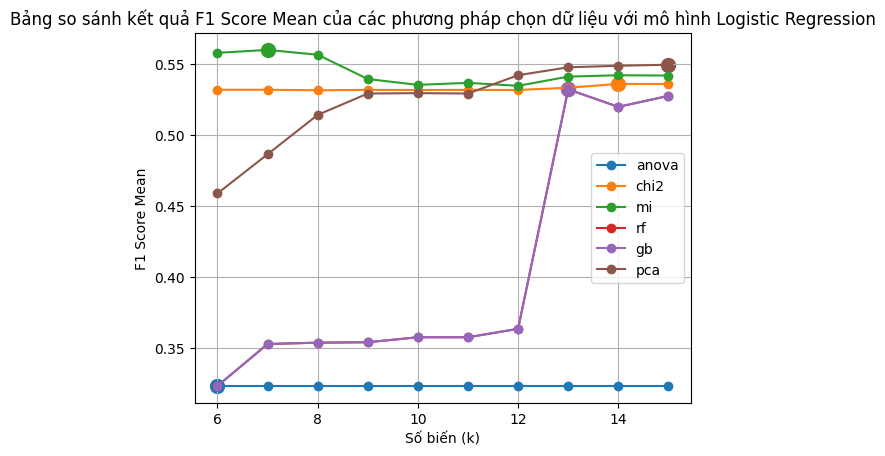

In [38]:
rows = []
for key, value in scores_mean.items():
    method, k = key.split("_")
    rows.append({
        "method": method,
        "k": int(k),
        "score": float(value)
    })

df_plot = pd.DataFrame(rows)

plt.figure()

for method in df_plot["method"].unique():
    subset = df_plot[df_plot["method"] == method].sort_values("k")
    plt.plot(subset["k"], subset["score"], marker='o', label=method)

    best = subset.loc[subset["score"].idxmax()]
    plt.scatter(best["k"], best["score"], s=100)

plt.xlabel("Số biến (k)")
plt.ylabel("F1 Score Mean")
plt.title("Bảng so sánh kết quả F1 Score Mean của các phương pháp chọn dữ liệu với mô hình Logistic Regression")
plt.legend()
plt.grid()

plt.show()

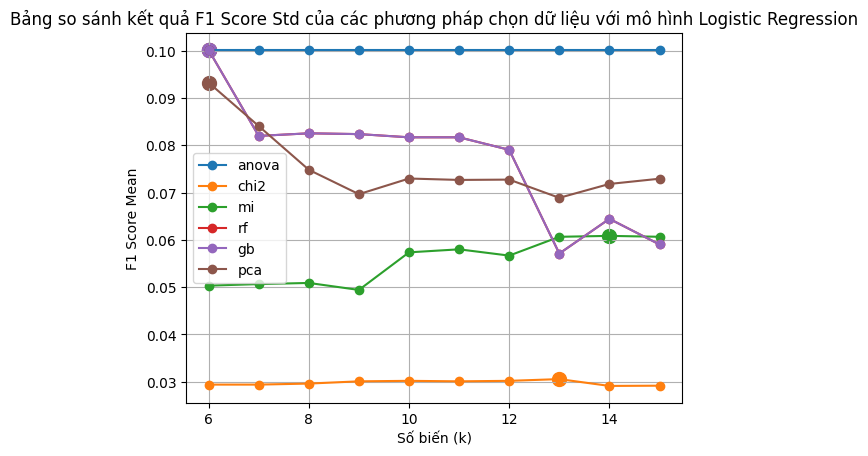

In [39]:
rows = []
for key, value in scores_std.items():
    method, k = key.split("_")
    rows.append({
        "method": method,
        "k": int(k),
        "score": float(value)
    })

df_plot = pd.DataFrame(rows)

plt.figure()

for method in df_plot["method"].unique():
    subset = df_plot[df_plot["method"] == method].sort_values("k")
    plt.plot(subset["k"], subset["score"], marker='o', label=method)

    best = subset.loc[subset["score"].idxmax()]
    plt.scatter(best["k"], best["score"], s=100)

plt.xlabel("Số biến (k)")
plt.ylabel("F1 Score Mean")
plt.title("Bảng so sánh kết quả F1 Score Std của các phương pháp chọn dữ liệu với mô hình Logistic Regression")
plt.legend()
plt.grid()

plt.show()

**Nhận xét**

1. Nhóm hiệu quả ổn định: Chi-square và Mutual Information
   * Mutual Information: Đạt F1 Score cao nhất (~0.56) khi chỉ cần 6-8 biến. Điều này cho thấy MI bắt được các mối quan hệ (cả tuyến tính và phi tuyến) rất tốt. Std khá thấp (~0.05), cho thấy MI mang lại kết quả tin cậy trên các tập dữ liệu khác nhau.
   * Chi-square: Duy trì mức F1 khoảng 0.53 - 0.54 xuyên suốt các giá trị $k$. Std duy trì ổn định ở mức thâp nhất (khoảng 0.3). Dù Chi-square chỉ dùng những biến phân loại đã được mã hoá nhưng kết quả thuộc nhóm cao nhất cho thấy việc các biến phân loại có ý nghĩa rất lớn trong dữ liệu, với cách mã hoá phù hợp, phương pháp này vượt trội hơn các phương pháp sử dụng kết hợp cả hai loại biến số và biến phân loại.
2. Nhóm hiệu quả tăng dần: PCA
   * PCA: Bắt đầu khá thấp ở $k=6$ nhưng tăng trưởng ổn định nhất. Đến $k=15$, PCA vượt qua tất cả các phương pháp khác để đạt F1 Score cao nhất (~0.55). Std giảm dần khi $k$ tăng và tăng nhẹ khi $k$ đạt 15. PCA không sử dụng cụ thể biến có sẵn mà tìm cách nén thông tin, khi số thành phần tăng, PCA giữ được nhiều thông tin gốc hơn, giúp mô hình hoạt động hiệu quả hơn trên các trục toạ độ mới.
3. Nhóm nhảy vọt: Gradient Boosting
   * Gradient Boosting: Hiệu suất rất tệ (khoảng 0.35) và bất ngờ nhảy vọt lên tại $k = 13$, đạt 0.53 F1 Score trung bình. Điều này cho thấy đặc trưng thứ 13 mà GB lựa chọn mang tính quyết định cực lớn đối với mô hình Logistic Regression. Tuy nhiên, sự nhảy vọt này đi kèm với rủi ro "ăn may" trên tập dữ liệu cụ thể.
4. Nhóm thất bại: ANOVA và Random Forest
   * ANOVA: Do ANOVA chỉ hoạt động trên dữ liệu gốc là biến số và số lượng biến số của dữ liệu chỉ có 6 nên mô hình thực chất chỉ được huấn luyện trên 6 biến dù $k$ có tăng. Kết quả F1 Score thấp nhất (khoảng 0.32) cho thấy các biến số không thể hiện được đầy đủ tính chất của dữ liệu.
   * Random Forest: Kết quả gần như trùng khít với ANOVA và tệ tương đương. Có thể do cách tính Feature Importance của RF (dựa trên cây) không tương thích với cách học của Logistic Regression (dựa trên hàm Logit).

In [40]:
rows = []

for key, features in features.items():
    method, k = key.split("_")
    
    num_count = sum(f in numeric_cols for f in features)
    cat_count = sum(f in categorical_cols for f in features)
    
    rows.append({
        "method": method,
        "k": int(k),
        "num_features": num_count,
        "cat_features": cat_count,
        "total": len(features)
    })

summary_df = pd.DataFrame(rows).sort_values(["method", "k"])
display(summary_df)

,method,k,num_features,cat_features,total
0,anova,6,6,0,6
3,anova,7,6,0,6
6,anova,8,6,0,6
9,anova,9,6,0,6
12,anova,10,6,0,6
15,anova,11,6,0,6
18,anova,12,6,0,6
21,anova,13,6,0,6
24,anova,14,6,0,6
27,anova,15,6,0,6


# Lưu trữ kết quả xử lý

In [44]:
df_process.to_csv("../data/processed/processed_tabular/adult.csv")